In [1]:
# python3 -m pip install --upgrade pip setuptools
# pip install -e .
# python -m ipykernel install --user --name=nome-do-seu-venv
%load_ext autoreload
%autoreload 2

# Home Credit — Previsão de Risco de Inadimplência

## Análise Exploratória de Dados (EDA) e Preparação de Dados

### Metodologia: CRISP-DM

Este notebook cobre as fases 1 a 5:

1. Definir o problema de negócio
2. Compreensão dos dados
3. Preparação de dados
4. Modelagem
5. Avaliação

# **1. DEFINIR O PROBLEMA DE NEGÓCIO**

A Home Credit busca ampliar a inclusão financeira da população desbancarizada, proporcionando uma experiência de crédito positiva e segura. Para garantir que esse público, frequentemente desatendido, tenha uma experiência positiva com o empréstimo, a Home Credit utiliza uma variedade de dados alternativos — incluindo informações de telecomunicações e dados transacionais — para prever a capacidade de pagamento de seus clientes.


A métrica que será utilizada para medirmos a eficiência do modelo será a curva ROC.

## **1.1 IMPORTANDO BIBLIOTECAS**

In [2]:
from pathlib import Path
from projeto import utils

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


# **2. COMPREENSÃO DOS DADOS** 

- O dataset foi coletado em: https://www.kaggle.com/competitions/home-credit-default-risk/data

- O conjunto de dados abrange múltiplos ficheiros relacionais estruturados para prever o risco de incumprimento de crédito (default), contendo dados demográficos e estáticos de pedidos de empréstimo, histórico de créditos anteriores em outras instituições (Credit Bureau), histórico de pagamentos, além de dados transacionais e de telecomunicações utilizados para avaliar a capacidade de pagamento de populações subatendidas.

Ana Lina Morelia, inversion, KirillOdintsov, and Martin Kotek. Home Credit Default Risk. https://kaggle.com/competitions/home-credit-default-risk, 2018. Kaggle.

## **2.1 COLETA E INTEGRAÇÃO INICIAL DE DADOS**

In [5]:
# Executa a função principal de carga e junção
df_train, df_test = utils.load_and_merge_home_credit_data()

Carregando application_train e application_test de /data/PROJETOS/GIT/HOME-CREDIT/data/raw...

=== Base de TREINO ===
Processando bureau e bureau_balance...
Processando previous_application.csv...


/data/PROJETOS/GIT/HOME-CREDIT/src/projeto/utils.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prev_agg.reset_index(inplace=True)


Processando POS_CASH_balance.csv...
Processando credit_card_balance.csv...
Processando installments_payments.csv...
Colunas: 122 -> 571 | linhas: 307511
Salvando em: /data/PROJETOS/GIT/HOME-CREDIT/data/bronze/train_merged.parquet

=== Base de TESTE ===
Processando bureau e bureau_balance...
Processando previous_application.csv...


/data/PROJETOS/GIT/HOME-CREDIT/src/projeto/utils.py:141: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prev_agg.reset_index(inplace=True)


Processando POS_CASH_balance.csv...
Processando credit_card_balance.csv...
Processando installments_payments.csv...
Colunas: 121 -> 570 | linhas: 48744
Salvando em: /data/PROJETOS/GIT/HOME-CREDIT/data/bronze/test_merged.parquet


# **3. PREPARAÇÃO DE DADOS**

In [6]:
def process_categorical_application(df_train: pd.DataFrame,
                                    df_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Converte colunas object para 'category' com o MESMO mapeamento em train e test."""
    df_train, df_test = df_train.copy(), df_test.copy()

    cat_cols = [
        'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
        'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
        'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
        'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
    ]
    cat_cols = [c for c in cat_cols if c in df_train.columns and c in df_test.columns]

    for col in cat_cols:
        cats = sorted(set(df_train[col].dropna().unique()) | set(df_test[col].dropna().unique()))
        dtype = pd.CategoricalDtype(categories=cats)
        df_train[col] = df_train[col].astype(dtype)
        df_test[col] = df_test[col].astype(dtype)

    print(f"{len(cat_cols)} colunas convertidas para 'category' com categorias alinhadas.")
    return df_train, df_test

In [8]:
df_train, df_test = process_categorical_application(df_train, df_test)

16 colunas convertidas para 'category' com categorias alinhadas.


# **4. MODELAGEM**

In [9]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


def train_lightgbm_model(df_train: pd.DataFrame, df_test: pd.DataFrame,
                         n_splits: int = 5, seed: int = 42):
    """Etapa 4 (Modelagem): StratifiedKFold + LightGBM. Não escreve arquivos."""
    print(f"Iniciando modelagem (seed={seed})...")

    drop_cols = ['SK_ID_CURR', 'TARGET']
    features = [c for c in df_train.columns if c not in drop_cols]

    faltando = [c for c in features if c not in df_test.columns]
    if faltando:
        raise ValueError(f"{len(faltando)} features ausentes no test: {faltando[:5]}")

    X, y = df_train[features], df_train['TARGET']
    X_test = df_test[features]

    folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_preds = np.zeros(len(df_train))
    sub_preds = np.zeros(len(df_test))
    importances = []

    for fold, (tr_idx, va_idx) in enumerate(folds.split(X, y)):
        print(f"\n--- Fold {fold + 1}/{n_splits} ---")
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(
            n_estimators=1000, learning_rate=0.03, num_leaves=34,
            subsample=0.8, colsample_bytree=0.8,
            random_state=seed, n_jobs=-1, verbose=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],          # só validação: acelera o treino
            eval_metric='auc',
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        oof_preds[va_idx] = model.predict_proba(X_va)[:, 1]
        sub_preds += model.predict_proba(X_test)[:, 1] / n_splits
        importances.append(pd.DataFrame({'feature': features,
                                         'importance': model.feature_importances_,
                                         'fold': fold}))
        print(f"AUC fold {fold + 1}: {roc_auc_score(y_va, oof_preds[va_idx]):.4f} "
              f"| best_iter: {model.best_iteration_}")

    overall_auc = roc_auc_score(y, oof_preds)
    print(f"\n{'=' * 32}\nROC-AUC OOF: {overall_auc:.4f}\n{'=' * 32}")

    submission = pd.DataFrame({'SK_ID_CURR': df_test['SK_ID_CURR'], 'TARGET': sub_preds})
    return submission, pd.concat(importances, ignore_index=True), oof_preds, overall_auc

In [10]:
sub, feature_imp, oof, auc_base = train_lightgbm_model(df_train, df_test)

Iniciando modelagem (seed=42)...

--- Fold 1/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 1: 0.7843 | best_iter: 665

--- Fold 2/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 2: 0.7922 | best_iter: 587

--- Fold 3/5 ---


...

AUC fold 3: 0.7836 | best_iter: 583

--- Fold 4/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 4: 0.7916 | best_iter: 950

--- Fold 5/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 5: 0.7845 | best_iter: 787

ROC-AUC OOF: 0.7872


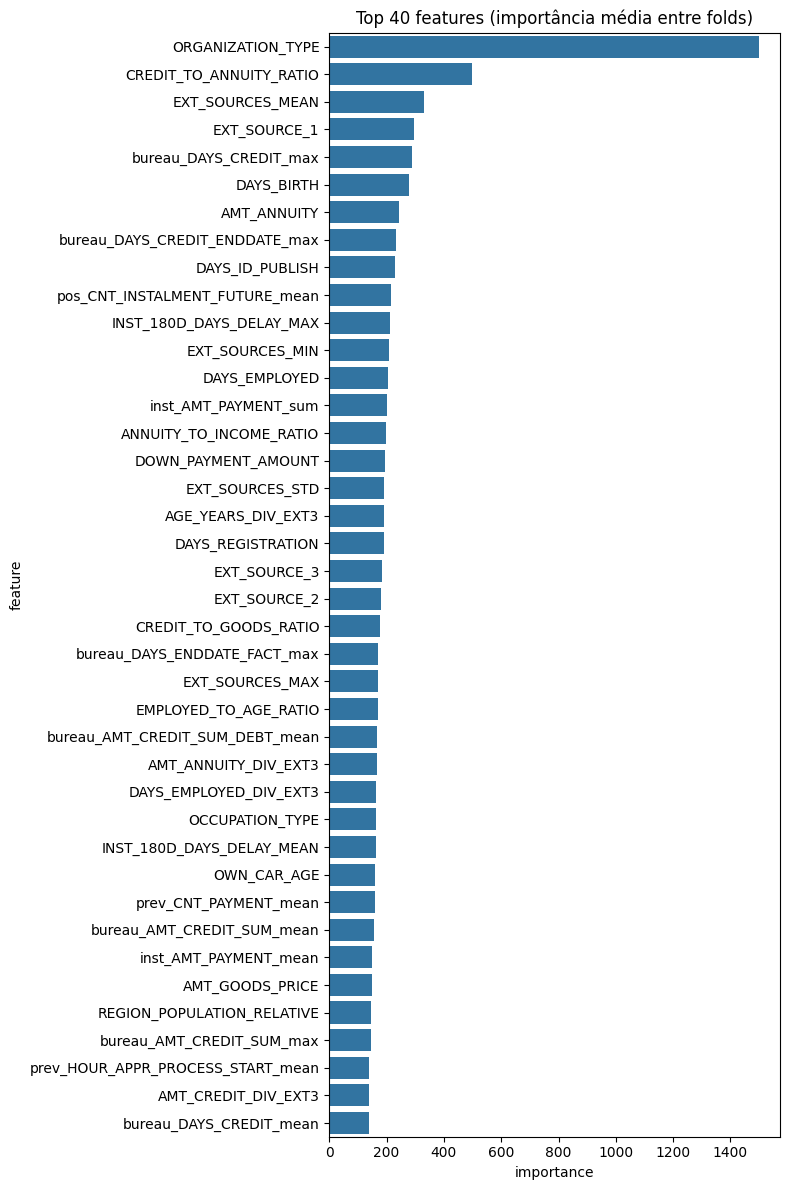

In [11]:
f = (feature_imp.groupby('feature')['importance']
     .mean()
     .sort_values(ascending=False)
     .head(40)
     .reset_index())

plt.figure(figsize=(8, 12))
sns.barplot(data=f, x='importance', y='feature', orient='h')
plt.title('Top 40 features (importância média entre folds)')
plt.tight_layout()
plt.show()

# **5. AVALIAÇÃO**

In [12]:
feature_imp_agg = feature_imp.groupby('feature')['importance'].sum().reset_index()
features_uteis = feature_imp_agg.loc[feature_imp_agg['importance'] > 0, 'feature'].tolist()

df_train_filtrado = df_train[features_uteis + ['SK_ID_CURR', 'TARGET']]
df_test_filtrado = df_test[features_uteis + ['SK_ID_CURR']]

print(f"Features originais: {df_train.shape[1] - 2}")
print(f"Features mantidas:  {len(features_uteis)}")
print(f"Descartadas:        {df_train.shape[1] - 2 - len(features_uteis)}")

Features originais: 569
Features mantidas:  488
Descartadas:        81


In [ ]:
sub, feature_imp_2, oof_2, auc_filtrado = train_lightgbm_model(
    df_train_filtrado, df_test_filtrado, seed=2024
)
print(f"\nAUC baseline : {auc_base:.4f}")
print(f"AUC filtrado : {auc_filtrado:.4f} ")

Iniciando modelagem (seed=2024)...

--- Fold 1/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 1: 0.7873 | best_iter: 606

--- Fold 2/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 2: 0.7847 | best_iter: 990

--- Fold 3/5 ---


...

AUC fold 3: 0.7894 | best_iter: 968

--- Fold 4/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 4: 0.7862 | best_iter: 640

--- Fold 5/5 ---


/data/PROJETOS/GIT/HOME-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC fold 5: 0.7867 | best_iter: 964

ROC-AUC OOF: 0.7868

AUC baseline : 0.7872
AUC filtrado : 0.7868  (seed diferente, comparação mais honesta)


In [14]:
from projeto.config import OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sub_path = OUTPUT_DIR / 'submission_lgb.csv'
sub.to_csv(sub_path, index=False)
print(f"Submissão salva em: {sub_path}  |  shape: {sub.shape}")

Submissão salva em: /data/PROJETOS/GIT/HOME-CREDIT/data/output/submission_lgb.csv  |  shape: (48744, 2)
